In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from pathlib import Path
from sklearn.decomposition import PCA

In [3]:
# Verificar datos de un sujeto
ruta = '../data/preprocessed_reshaped/S01_EEG.npz'
data = np.load(ruta)
print('keys:', list(data.keys()))
print('x shape:', data['x'].shape)
print('y shape:', data['y'].shape)
print('y sample:', data['y'][:3])

keys: ['x', 'y']
x shape: (688, 6, 512)
y shape: (688, 3)
y sample: [[ 1.  9.  2.]
 [ 1. 11.  2.]
 [ 1.  9.  2.]]


In [10]:
DATA_DIR = Path('../data/preprocessed_reshaped')
N_TRIALS = 100
N_PCA = 100

all_X = []
all_labels = []

subject_files = sorted(DATA_DIR.glob('S*_EEG.npz'))
print(f'Encontrados {len(subject_files)} archivos de sujetos')

for subj_file in subject_files:
    d = np.load(subj_file)
    X = d['x']  # (trials, 6, 512)
    idx = np.random.RandomState(42).permutation(len(X))[:N_TRIALS]
    all_X.append(X[idx])
    subj_id = int(subj_file.stem.split('_')[0].replace('S', '')) - 1
    all_labels.extend([subj_id] * N_TRIALS)
    print(f'{subj_file.stem}: {X.shape[0]} trials disponibles, muestreadas {N_TRIALS}')

X_all = np.vstack(all_X)
labels = np.array(all_labels)
print(f'\nMatriz total: X={X_all.shape}, labels={labels.shape}')
print(f'Etiquetas unicas (sujetos): {np.unique(labels)}')

Encontrados 15 archivos de sujetos
S01_EEG: 688 trials disponibles, muestreadas 100
S02_EEG: 611 trials disponibles, muestreadas 100
S03_EEG: 641 trials disponibles, muestreadas 100
S04_EEG: 603 trials disponibles, muestreadas 100
S05_EEG: 573 trials disponibles, muestreadas 100
S06_EEG: 607 trials disponibles, muestreadas 100
S07_EEG: 584 trials disponibles, muestreadas 100
S08_EEG: 634 trials disponibles, muestreadas 100
S09_EEG: 645 trials disponibles, muestreadas 100
S10_EEG: 631 trials disponibles, muestreadas 100
S11_EEG: 628 trials disponibles, muestreadas 100
S12_EEG: 614 trials disponibles, muestreadas 100
S13_EEG: 621 trials disponibles, muestreadas 100
S14_EEG: 639 trials disponibles, muestreadas 100
S15_EEG: 596 trials disponibles, muestreadas 100

Matriz total: X=(1500, 6, 512), labels=(1500,)
Etiquetas unicas (sujetos): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [17]:
# Reduccion de dimensionalidad con PCA antes de t-SNE
print(f'Aplicando PCA a {N_PCA} componentes...')
pca = PCA(n_components=N_PCA, random_state=42)
#X_pca = pca.fit_transform(X_all.reshape(len(X_all), -1))
X_pca = X_all.reshape(len(X_all), -1)
#print(f'Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}')
print(f'Shape tras PCA: {X_pca.shape}')

Aplicando PCA a 100 componentes...
Shape tras PCA: (1500, 3072)


In [18]:
# t-SNE
print('Entrenando t-SNE (puede tardar unos minutos)...')
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca)
print('t-SNE completado')
print(f'Shape resultado: {X_tsne.shape}')

Entrenando t-SNE (puede tardar unos minutos)...
t-SNE completado
Shape resultado: (1500, 2)


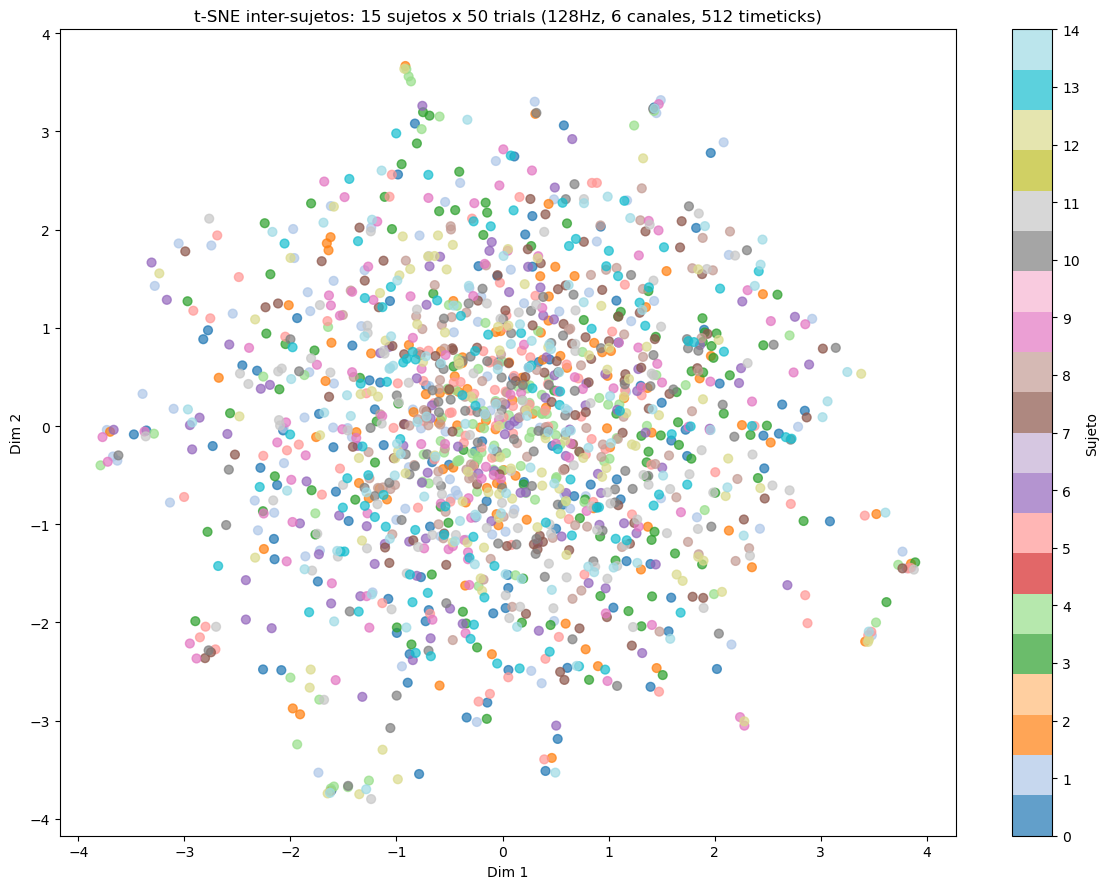

In [19]:
# Visualizacion
fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab20', s=40, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(15))
cbar.set_label('Sujeto')
ax.set_title('t-SNE inter-sujetos: 15 sujetos x 50 trials (128Hz, 6 canales, 512 timeticks)')
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
plt.tight_layout()
plt.savefig('../tsne_inter_subjects_128hz.png', dpi=150)
plt.show()

## Clasificacion inter-sujetos con ML clasico

Probar si clasificadores classicos pueden identificar de que sujeto pertenece cada trial.
Se usa **todos los trials** de los 15 sujetos y **5-fold CV**. PCA a 50 componentes como preprocesamiento.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Cargar todos los trials de todos los sujetos
DATA_DIR = Path('../data/eeg_128hz')
N_PCA = 50

all_X = []
all_labels = []

for subj_file in sorted(DATA_DIR.glob('S*_EEG.npz')):
    d = np.load(subj_file)
    X = d['x']
    all_X.append(X)
    subj_id = int(subj_file.stem.split('_')[0].replace('S', '')) - 1
    all_labels.extend([subj_id] * len(X))

X_all = np.vstack(all_X)
labels = np.array(all_labels)
n_subjects = len(np.unique(labels))

X_flat = X_all.reshape(len(X_all), -1)  # (9315, 3072)
print(f'Dataset: {X_flat.shape[0]} trials, {X_flat.shape[1]} features, {n_subjects} sujetos')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'SVM (RBF)': Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))]),
    'KNN (k=5)': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('scaler', StandardScaler()), ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42))])
}

results = {}
for name, model in models.items():
    print(f'Entrenando {name}...')
    scores = cross_val_score(model, X_flat, labels, cv=cv, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'  Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})')

In [ ]:
# Tabla resumen
import pandas as pd

df_results = pd.DataFrame({
    name: [f"{v['mean']:.3f} (+/- {v['std']:.3f})"]
    for name, v in results.items()
}).T
df_results.columns = ['Accuracy (5-fold CV)']
df_results = df_results.sort_values('Accuracy (5-fold CV)', ascending=False)
print('=== Resultados ===')
print(df_results)

# Mejor modelo
best_model_name = max(results, key=lambda k: results[k]['mean'])
print(f'\nMejor clasificador: {best_model_name} ({results[best_model_name]["mean"]:.3f})')

In [ ]:
# Entrenar mejor modelo sobre todos los datos para ver confusion matrix
# Usamos SVM (RBF) como referencia
from sklearn.model_selection import cross_val_predict

model_final = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))])
y_pred = cross_val_predict(model_final, X_flat, labels, cv=cv)

print('=== Classification Report (SVM RBF) ===')
print(classification_report(labels, y_pred, target_names=[f'S{i+1:02d}' for i in range(n_subjects)]))

In [ ]:
# Confusion matrix
import seaborn as sns

cm = confusion_matrix(labels, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f'S{i+1:02d}' for i in range(n_subjects)],
            yticklabels=[f'S{i+1:02d}' for i in range(n_subjects)])
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusion (SVM RBF, 5-fold CV) - 15 sujetos')
plt.tight_layout()
plt.savefig('../confusion_matrix_inter_subjects.png', dpi=150)
plt.show()

In [ ]:
# Grafico de comparacion de modelos
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds = [results[n]['std'] for n in names]

colors = ['#2ecc71' if m == max(means) else '#3498db' for m in means]
bars = ax.barh(names, means, xerr=stds, color=colors, alpha=0.8, capsize=5)
ax.set_xlabel('Accuracy')
ax.set_title('Comparacion de clasificadores - Identificacion de sujeto (5-fold CV)')
ax.set_xlim(0, 1.0)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.01, bar.get_y() + bar.get_height()/2, f'{mean:.3f}', va='center')
plt.tight_layout()
plt.savefig('../ml_models_comparison.png', dpi=150)
plt.show()